In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import glob
import re

from IPython.display import display

In [2]:
def calculate_apdex(df, threshold=500):
    satisfied = (df['elapsed'] <= threshold).sum()
    tolerating = ((df['elapsed'] > threshold) & (df['elapsed'] <= 4 * threshold)).sum()
    total = len(df)
    return (satisfied + tolerating / 2) / total if total > 0 else 0.0

In [3]:
def process_file(file, apdex_threshold=500):
    df = pd.read_csv(file, sep=';', encoding='utf-8-sig')
    df.columns = df.columns.str.strip().str.lower()

    df['success'] = df['success'].astype(str).str.lower() == 'true'

    total = len(df)
    success = df['success'].sum()
    error = total - success

    match = re.search(r'Idle.*?(\d+)', file, re.IGNORECASE)
    users = int(match.group(1)) if match else None

    if not df.empty:
        start_time = df['timestamp'].min()
        end_time = df['timestamp'].max()
        duration_sec = (end_time - start_time) / 1000.0
        throughput = total / duration_sec if duration_sec > 0 else 0
    else:
        throughput = 0

    p90 = df['elapsed'].quantile(0.90) if not df.empty else 0
    p95 = df['elapsed'].quantile(0.95) if not df.empty else 0
    p99 = df['elapsed'].quantile(0.99) if not df.empty else 0

    apdex = calculate_apdex(df, threshold=apdex_threshold)

    return {
        'users': users,
        'total_requests': total,
        'success_rate (%)': round(success / total * 100, 2) if total > 0 else 0,
        'error_rate (%)': round(error / total * 100, 2) if total > 0 else 0,
        'avg_response (ms)': round(df['elapsed'].mean(), 2) if not df.empty else 0,
        'p90_response (ms)': round(p90, 2),
        'p95_response (ms)': round(p95, 2),
        'avg_latency (ms)': round(df['latency'].mean(), 2) if not df.empty else 0,
        'avg_connect (ms)': round(df['connect'].mean(), 2) if 'connect' in df.columns and not df.empty else 0,
        'throughput (req/s)': round(throughput, 2),
        'apdex': round(apdex, 3),
    }

In [4]:
def analyze_all(pattern="IdleReport/Wordpress Report - Idle*.csv", apdex_threshold=500):
    files = glob.glob(pattern)
    if not files:
        print(f"Format file salah: {pattern}")
        return pd.DataFrame()

    results = []
    for f in sorted(files):
        results.append(process_file(f, apdex_threshold))

    df_result = pd.DataFrame(results)

    if df_result['users'].notna().all():
        df_result = df_result.sort_values(by='users').reset_index(drop=True)

    numeric_cols = df_result.select_dtypes(include='number').columns
    avg_values = df_result[numeric_cols].mean()

    avg_row = avg_values.to_dict()
    avg_row['users'] = 'Average'

    df_final = pd.concat([df_result, pd.DataFrame([avg_row])], ignore_index=True)

    cols = ['users'] + [col for col in df_final.columns if col != 'users']
    df_final = df_final[cols]

    return df_final

In [5]:
result = analyze_all("IdleReport/Wordpress Report - Idle*.csv", apdex_threshold=500)
result.to_csv("Wordpress Report - Idle Summary.csv", index=False)

styled = (result.style
          .hide(axis="index")
          .format(precision=2)
          .apply(lambda row: ['font-weight: bold' 
                              if row.name == len(result)-1 else '' 
                              for _ in row], axis=1)
         )

display(styled)

users,total_requests,success_rate (%),error_rate (%),avg_response (ms),p90_response (ms),p95_response (ms),avg_latency (ms),avg_connect (ms),throughput (req/s),apdex
1,4362.00,100.00,0.00,137.39,160.00,184.95,108.22,0.52,7.27,1.00
2,7483.00,100.00,0.00,158.27,194.00,229.00,124.27,0.51,12.48,1.00
3,7370.00,99.97,0.03,240.21,317.00,361.00,146.97,0.58,12.28,0.99
4,9859.00,100.00,0.00,238.82,342.20,444.10,174.31,0.68,16.44,0.98
5,9579.00,99.99,0.01,306.89,427.00,495.00,199.90,1.13,15.97,0.97
Average,7730.60,99.99,0.01,216.32,288.04,342.81,150.73,0.68,12.89,0.99


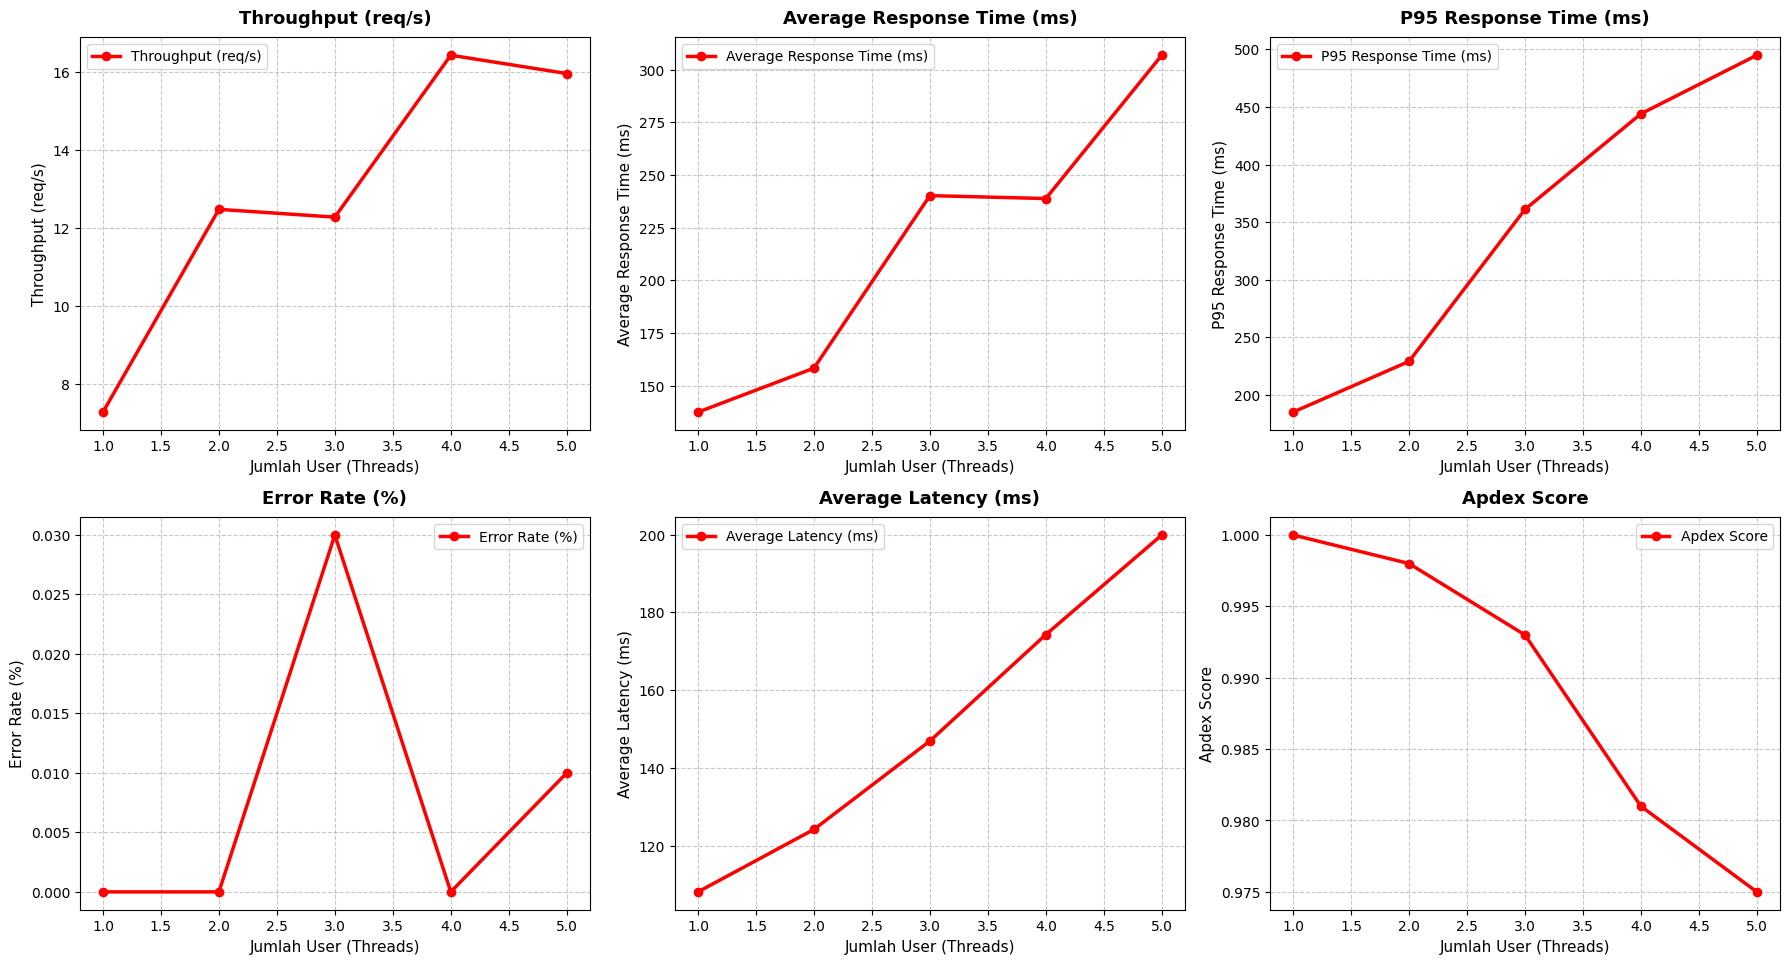

In [6]:
fig, axs = plt.subplots(3, 3, figsize=(18, 15))

x = result['users'][:-1]

metrics = [
    ('throughput (req/s)',    'Throughput (req/s)',          'red'),
    ('avg_response (ms)',     'Average Response Time (ms)',  'red'),
    ('p95_response (ms)',     'P95 Response Time (ms)',      'red'),
    ('error_rate (%)',        'Error Rate (%)',              'red'),
    ('avg_latency (ms)',      'Average Latency (ms)',        'red'),
    ('apdex',                 'Apdex Score',                 'red'),
]

for i, (col, title, color) in enumerate(metrics):
    row, col_idx = divmod(i, 3)
    
    axs[row, col_idx].plot(x, result[col][:-1], 
                           marker='o', linewidth=2.5, color=color, label=title)
    
    axs[row, col_idx].set_title(title, fontsize=13, fontweight='bold', pad=10)
    axs[row, col_idx].set_xlabel("Jumlah User (Threads)", fontsize=11)
    axs[row, col_idx].set_ylabel(title, fontsize=11)
    axs[row, col_idx].grid(True, linestyle='--', alpha=0.7)
    axs[row, col_idx].legend(fontsize=10)

for j in range(6, 9):
    axs.flat[j].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("Wordpress Report - Idle.png")
plt.show()

In [7]:
def clean_cpu(val):
    if pd.isna(val):
        return 0
    val_str = str(val).strip().lower()
    match = re.search(r'(\d+\.?\d*)', val_str)
    if not match:
        return 0
    value = float(match.group(1))
    if 'm' in val_str:
        return value
    else:
        return value * 1000

In [8]:
def clean_memory(val):
    if pd.isna(val):
        return 0
    val_str = str(val).strip().lower()
    match = re.search(r'(\d+\.?\d*)', val_str)
    if not match:
        return 0
    
    value = float(match.group(1))
    
    if 'gi' in val_str:
        return value * 1024
    elif 'mi' in val_str or 'mib' in val_str:
        return value
    elif 'ki' in val_str:
        return value / 1024
    else:
        return value

In [9]:
pattern = "IdleResult/log_wordpress-idle_*-user.csv"
files = glob.glob(pattern)

results = []
for file in sorted(files):
    try:
        match = re.search(r'_(\d+)-user', file)
        user_count = int(match.group(1)) if match else 0
        
        df = pd.read_csv(file)
        
        df['CPU_cleaned'] = df['CPU_m'].apply(clean_cpu)
        df['Memory_cleaned'] = df['Memory_Mi'].apply(clean_memory)
        
        avg_cpu = df['CPU_cleaned'].mean()
        max_cpu = df['CPU_cleaned'].max()
        avg_mem = df['Memory_cleaned'].mean()
        max_mem = df['Memory_cleaned'].max()
        
        results.append({
            'Users': f"{user_count}",
            'Avg CPU (m)': round(avg_cpu, 2),
            'Max CPU (m)': round(max_cpu, 2),
            'Avg Memory (Mi)': round(avg_mem, 2),
            'Max Memory (Mi)': round(max_mem, 2),
            'Samples': len(df)
        })
        
    except Exception as e:
        print(f"Error processing {file}: {e}")

summary_df = pd.DataFrame(results)

In [10]:
numeric_cols = ['Avg CPU (m)', 'Max CPU (m)', 'Avg Memory (Mi)', 'Max Memory (Mi)', 'Samples']
avg_row = summary_df[numeric_cols].mean()
avg_row['Users'] = 'Average'

summary = pd.concat([summary_df, pd.DataFrame([avg_row])], ignore_index=True)
summary.to_csv("Wordpress Result - Idle Summary.csv", index=False)

styled = (summary.style
          .hide(axis="index")
          .format(precision=2)
          .apply(lambda row: ['font-weight: bold' 
                              if row.name == len(summary)-1 else '' 
                              for _ in row], axis=1)
         )

display(styled)

Users,Avg CPU (m),Max CPU (m),Avg Memory (Mi),Max Memory (Mi),Samples
1,128.96,297.00,291.59,455.00,288.00
2,178.64,448.00,247.72,458.00,369.00
3,180.78,543.00,236.38,460.00,364.00
4,178.13,787.00,219.76,459.00,512.00
5,169.48,638.00,223.14,460.00,516.00
Average,167.20,542.60,243.72,458.40,409.80


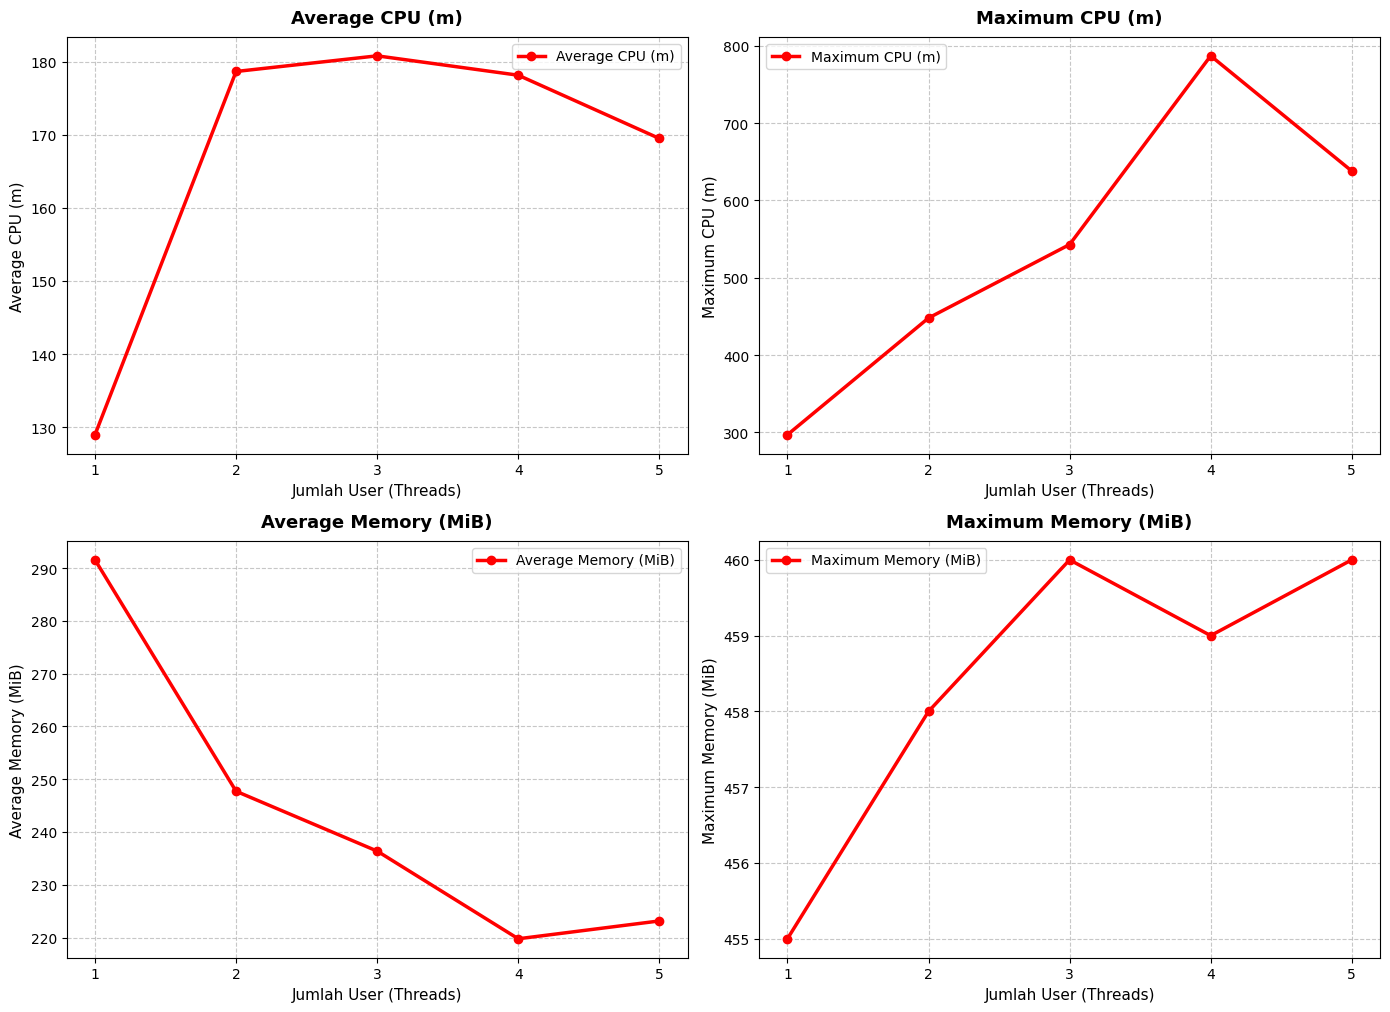

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(14, 11))

x = summary['Users'][:-1]

metrics = [
    ('Avg CPU (m)',     'Average CPU (m)',             'red'),
    ('Max CPU (m)',     'Maximum CPU (m)',             'red'),
    ('Avg Memory (Mi)', 'Average Memory (MiB)',        'red'),
    ('Max Memory (Mi)', 'Maximum Memory (MiB)',        'red'),
]

for i, (col, title, color) in enumerate(metrics):
    row, col_idx = divmod(i, 2)
    
    axs[row, col_idx].plot(x, summary[col][:-1], 
                           marker='o', linewidth=2.5, color=color, label=title)
    
    axs[row, col_idx].set_title(title, fontsize=13, fontweight='bold', pad=10)
    axs[row, col_idx].set_xlabel("Jumlah User (Threads)", fontsize=11)
    axs[row, col_idx].set_ylabel(title, fontsize=11)
    axs[row, col_idx].grid(True, linestyle='--', alpha=0.7)
    axs[row, col_idx].legend(fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("Wordpress Result - Idle.png")
plt.show()